# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "cfc113"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[77.09 77.13633333333333 77.18266666666666 ... 82.73133333333334 83.138 85.751] [77.09 77.13633333333333 77.33872727272727 ... 84.11966666666667 84.93533333333335 85.751] [77.09 77.21436363636364 77.84528571428572 ... 83.6205 84.51377777777779 85.751] [77.09 77.66754545454545 78.2450909090909 ... 83.27655555555555 84.16983333333333 85.751] [77.09 77.13633333333333 77.44827272727272 ... 82.93261111111111 83.8258888888889 85.751] [77.09 77.13633333333334 77.18266666666666 ... 82.58866666666667 83.48194444444445 85.751]] [[76.92 77.26700000000001 77.614 ... 83.08633333333334 83.287 85.954] [76.92 77.267 77.57145454545454 ... 84.93400000000001 85.444 85.954] [76.92 77.24572727272728 77.88485714285714 ... 83.95575000000001 84.76955555555556 85.954] [76.92 77.69681818181817 78.47363636363636 ... 83.5851111111111 84.39891666666666 85.954] [76.92 77.267 77.8289090909091 ... 83.21447222222223 84.02827777777777 85.954] [76.92 77.267 77.61399999999999 ... 82.84383333333334 83.6576388888889 85.954]] [[81.429 80.43833333333333 79.44766666666666 ... 83.17166666666667 83.606 85.789] [81.429 80.43833333333333 79.74881818181818 ... 85.05366666666667 85.42133333333334 85.789] [81.429 80.5889090909091 80.71964285714286 ... 83.956 84.73177777777776 85.789] [81.429 81.45490909090908 81.48081818181818 ... 83.67455555555556 84.45033333333333 85.789] [81.429 80.43833333333333 79.95595454545453 ... 83.39311111111111 84.16888888888889 85.789] [81.429 80.43833333333333 79.44766666666666 ... 83.11166666666666 83.88744444444444 85.789]] ... [[66.986 66.8599 66.8235 ... 67.0055 67.086 66.872] [66.986 66.83 66.841 ... 66.89533333333333 66.88366666666667 66.872] [66.986 66.91176470588235 66.91929411764706 ... 66.972 67.0 66.872] [66.986 66.97661904761905 66.9672380952381 ... 66.98614285714285 67.02149999999999 66.872] [66.986 66.91969999999999 66.89680952380952 ... 67.00764285714286 67.04299999999999 66.872] [66.986 66.88980000000001 66.8534 ... 67.02914285714286 67.06450000000001 66.872]] [[66.875 66.875 66.8195 ... 66.96600000000001 67.046 66.852] [66.875 66.875 66.87614285714285 ... 66.87266666666666 66.86233333333334 66.852] [66.875 66.875 66.85430000000001 ... 66.953 66.965 66.852] [66.875 66.875 66.8195 ... 66.94785714285715 66.98525000000001 66.852] [66.875 66.875 66.8195 ... 66.96810714285715 67.00550000000001 66.852] [66.875 66.875 66.81949999999999 ... 66.98835714285715 67.02575000000002 66.852]] [[66.83 66.83 66.76650000000001 ... 66.884 66.918 66.906] [66.83 66.83 66.83628571428571 ... 66.88466666666666 66.89533333333334 66.906] [66.83 66.83 66.8041 ... 66.886 66.85 66.906] [66.83 66.83 66.76650000000001 ... 66.83871428571429 66.86699999999999 66.906] [66.83 66.83 66.76650000000001 ... 66.8557142857143 66.884 66.906] [66.83 66.83 66.76650000000001 ... 66.8727142857143 66.90100000000001 66.906]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[77.09 77.13633333333333 77.18266666666666 ... 82.73133333333334 83.138 85.751] [77.09 77.13633333333333 77.33872727272727 ... 84.11966666666667 84.93533333333335 85.751] [77.09 77.21436363636364 77.84528571428572 ... 83.6205 84.51377777777779 85.751] [77.09 77.66754545454545 78.2450909090909 ... 83.27655555555555 84.16983333333333 85.751] [77.09 77.13633333333333 77.44827272727272 ... 82.93261111111111 83.8258888888889 85.751] [77.09 77.13633333333334 77.18266666666666 ... 82.58866666666667 83.48194444444445 85.751]] [[76.92 77.26700000000001 77.614 ... 83.08633333333334 83.287 85.954] [76.92 77.267 77.57145454545454 ... 84.93400000000001 85.444 85.954] [76.92 77.24572727272728 77.88485714285714 ... 83.95575000000001 84.76955555555556 85.954] [76.92 77.69681818181817 78.47363636363636 ... 83.5851111111111 84.39891666666666 85.954] [76.92 77.267 77.8289090909091 ... 83.21447222222223 84.02827777777777 85.954] [76.92 77.267 77.61399999999999 ... 82.84383333333334 83.6576388888889 85.954]] [[81.429 80.43833333333333 79.44766666666666 ... 83.17166666666667 83.606 85.789] [81.429 80.43833333333333 79.74881818181818 ... 85.05366666666667 85.42133333333334 85.789] [81.429 80.5889090909091 80.71964285714286 ... 83.956 84.73177777777776 85.789] [81.429 81.45490909090908 81.48081818181818 ... 83.67455555555556 84.45033333333333 85.789] [81.429 80.43833333333333 79.95595454545453 ... 83.39311111111111 84.16888888888889 85.789] [81.429 80.43833333333333 79.44766666666666 ... 83.11166666666666 83.88744444444444 85.789]] ... [[66.986 66.8599 66.8235 ... 67.0055 67.086 66.872] [66.986 66.83 66.841 ... 66.89533333333333 66.88366666666667 66.872] [66.986 66.91176470588235 66.91929411764706 ... 66.972 67.0 66.872] [66.986 66.97661904761905 66.9672380952381 ... 66.98614285714285 67.02149999999999 66.872] [66.986 66.91969999999999 66.89680952380952 ... 67.00764285714286 67.04299999999999 66.872] [66.986 66.88980000000001 66.8534 ... 67.02914285714286 67.06450000000001 66.872]] [[66.875 66.875 66.8195 ... 66.96600000000001 67.046 66.852] [66.875 66.875 66.87614285714285 ... 66.87266666666666 66.86233333333334 66.852] [66.875 66.875 66.85430000000001 ... 66.953 66.965 66.852] [66.875 66.875 66.8195 ... 66.94785714285715 66.98525000000001 66.852] [66.875 66.875 66.8195 ... 66.96810714285715 67.00550000000001 66.852] [66.875 66.875 66.81949999999999 ... 66.98835714285715 67.02575000000002 66.852]] [[66.83 66.83 66.76650000000001 ... 66.884 66.918 66.906] [66.83 66.83 66.83628571428571 ... 66.88466666666666 66.89533333333334 66.906] [66.83 66.83 66.8041 ... 66.886 66.85 66.906] [66.83 66.83 66.76650000000001 ... 66.83871428571429 66.86699999999999 66.906] [66.83 66.83 66.76650000000001 ... 66.8557142857143 66.884 66.906] [66.83 66.83 66.76650000000001 ... 66.8727142857143 66.90100000000001 66.906]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'cfc113' (lon: 6, lat: 12, year: 31, month: 12)> Size: 214kB
<Quantity([[[[79.959      80.722      82.286      ... 82.225      83.286
    82.223     ]
   [81.976      82.184      82.791      ... 83.488      83.664
    83.271     ]
   [83.401      82.722      82.457      ... 83.09       83.259
    83.398     ]
   ...
   [68.712      68.617      68.564      ... 68.178      68.181
    68.166     ]
   [68.079      67.967      67.839      ... 67.612      67.594
    67.605     ]
   [67.595      67.539      67.429      ... 67.117      67.015
    67.036     ]]

  [[79.80166667 80.271      81.36133333 ... 81.86833333 82.46616667
    81.8305    ]
   [81.609      82.01333333 82.57233333 ... 83.24116667 83.37933333
    83.20733333]
   [83.2855     82.74333333 82.4475     ... 83.03916667 83.14083333
    83.19516667]
...
   [68.6935     68.734      68.7165     ... 68.0025     68.023
    68.091     ]
   [68.146      68.134      68.07775    ... 67.5        67.54775
    67.59375   ]
   [67.58025    67.572      67.5665     ... 66.96325    66.9765
    67.00375   ]]

  [[85.507      85.293      85.634      ... 85.617      85.784
    86.172     ]
   [85.664      85.         85.49       ... 85.333      85.568
    85.32      ]
   [85.19       85.271      85.427      ... 84.94       85.016
    84.995     ]
   ...
   [68.697      68.722      68.658      ... 68.075      68.071
    68.135     ]
   [68.199      68.167      68.026      ... 67.559      67.556
    67.51      ]
   [67.527      67.549      67.574      ... 66.898      66.896
    66.909     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 248B 1993 1994 1995 1996 1997 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[79.959 80.722 82.286 ... 67.117 67.015 67.036] [79.80166666666666 80.271 81.36133333333333 ... 67.00710000000001 66.9642 66.99730000000001] [79.64433333333334 79.82000000000001 80.43666666666667 ... 66.96950000000001 66.959 66.9505] ... [82.78033333333333 83.10933333333332 83.74833333333333 ... 66.955 66.989 66.97999999999999] [83.009 83.395 84.182 ... 66.982 66.993 66.99] [85.507 85.293 85.634 ... 66.898 66.896 66.909]] [[79.959 80.722 82.286 ... 67.117 67.015 67.036] [79.80166666666666 80.27099999999999 81.36133333333332 ... 66.983 66.949 67.0] [79.76172727272727 80.13636363636363 80.80036363636363 ... 66.99185714285714 66.95957142857142 66.99614285714286] ... [84.59766666666667 84.68766666666667 84.92333333333333 ... 66.996 66.98066666666666 66.95166666666667] [85.05233333333334 84.99033333333334 85.27866666666667 ... 66.94699999999999 66.93833333333333 66.93033333333334] [85.507 85.293 85.634 ... 66.898 66.896 66.909]] [[79.959 80.722 82.286 ... 67.117 67.015 67.036] [79.86036363636364 80.42918181818182 81.54318181818182 ... 67.03705882352942 66.97470588235294 67.01188235294117] [80.21757142857143 80.8365 81.69957142857143 ... 67.01117647058824 66.96011764705882 66.99964705882353] ... [84.00200000000001 83.812 84.10350000000001 ... 66.83 66.858 66.914] [84.56055555555555 84.4238888888889 84.79244444444444 ... 66.907 66.927 67.045] [85.507 85.293 85.634 ... 66.898 66.896 66.909]] [[79.959 80.722 82.286 ... 67.117 67.015 67.036] [80.29645454545454 80.93199999999999 82.24127272727273 ... 67.08200000000001 66.99785714285714 67.01795238095238] [80.63390909090909 81.142 82.19654545454544 ... 67.04700000000001 66.98071428571428 66.99990476190476] ... [83.61411111111111 83.55477777777777 83.95088888888888 ... 66.92471428571429 66.94242857142858 67.01657142857142] [84.17266666666667 84.16666666666667 84.63983333333333 ... 66.92575 66.9435 67.03124999999999] [85.507 85.293 85.634 ... 66.898 66.896 66.909]] [[79.959 80.722 82.286 ... 67.117 67.015 67.036] [79.80166666666666 80.271 81.36133333333333 ... 67.0553 66.99459999999999 66.9919] [79.89172727272727 80.1505 80.87663636363636 ... 67.019 66.98342857142858 66.95947619047618] ... [83.22622222222222 83.29755555555556 83.79827777777778 ... 66.94346428571428 66.95892857142857 67.00282142857144] [83.78477777777778 83.90944444444445 84.48722222222221 ... 66.94449999999999 66.96 67.0175] [85.507 85.293 85.634 ... 66.898 66.896 66.909]] [[79.959 80.722 82.286 ... 67.117 67.015 67.036] [79.80166666666666 80.271 81.36133333333333 ... 67.03120000000001 66.97940000000001 66.9946] [79.64433333333332 79.82 80.43666666666667 ... 66.9936 66.9742 66.9478] ... [82.83833333333334 83.04033333333334 83.64566666666667 ... 66.9622142857143 66.97542857142857 66.98907142857142] [83.3968888888889 83.65222222222222 84.33461111111112 ... 66.96325 66.9765 67.00375] [85.507 85.293 85.634 ... 66.898 66.896 66.909]]]
Units,ppt


### Longitudinal-mean

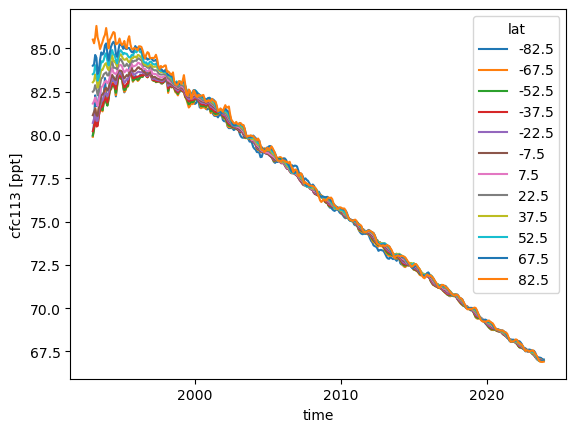

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

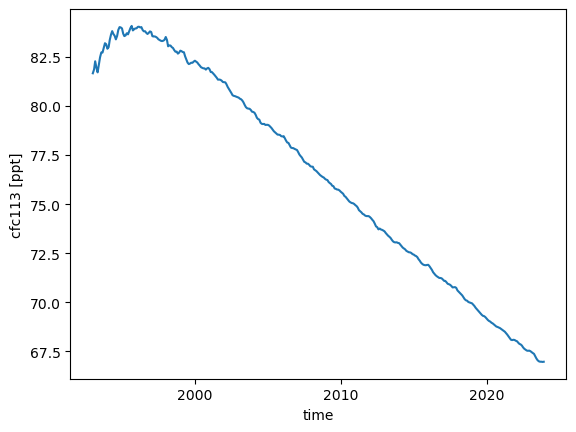

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

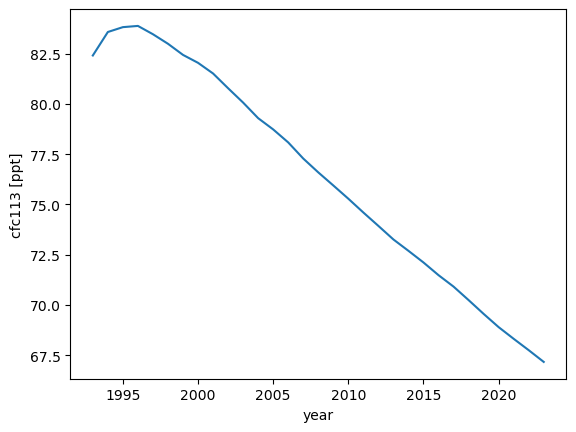

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 5kB
Dimensions:               (lat: 12, eof: 12, year: 31)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 248B 1993 1994 1995 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.182 ... -0.05329
    principal-components  (year, eof) float64 3kB [] -4.813 ... 4.587e-15

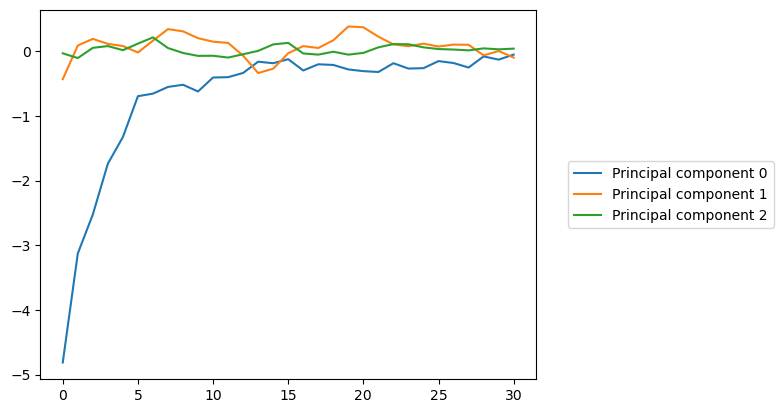

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

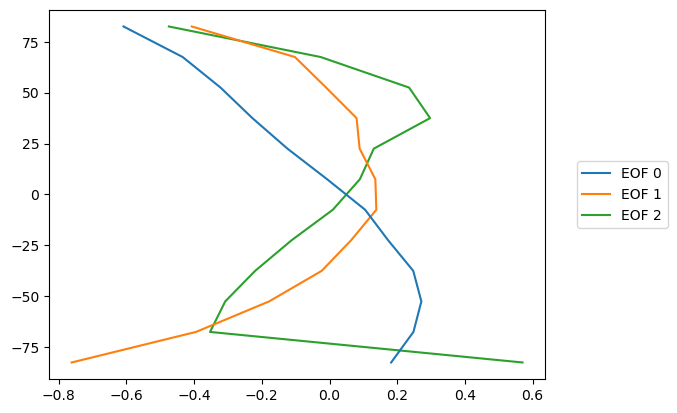

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

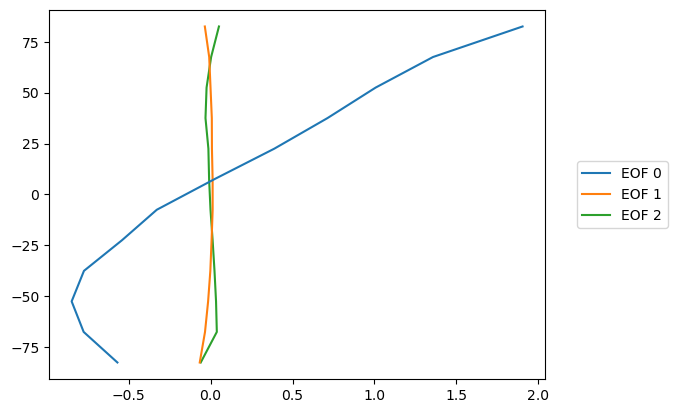

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.18199277152761673] [0.24784019585397316] [0.2712928553908306] [0.24725244922242925] [0.1732081517124007] [0.10513456823146512] [-0.0072338594128509215] [-0.12422351730821722] [-0.22785836256714267] [-0.3219717114415246] [-0.43381634241216] [-0.6086052036112238]]
Units,ppt
Magnitude,[[-4.813315531600496] [-3.128032057548855] [-2.5244599356646384] [-1.7394435270762652] [-1.3277161385573188] [-0.6958437667970072] [-0.656304245082901] [-0.5523870711835934] [-0.5192037449211997] [-0.6227200931681147] [-0.40674670622211] [-0.40158002180694935] [-0.3362729728382087] [-0.16218128548382185] [-0.18620019729145726] [-0.1235706027149398] [-0.29860305501029644] [-0.20258918481357974] [-0.2127369662001422] [-0.2822067333922683] [-0.3085754578492048] [-0.32163721183474453] [-0.18593876728793685] [-0.268678081519657] [-0.26233371601465333] [-0.15316733909503105] [-0.18298431640389076] [-0.25301375272916077] [-0.08097379490614735] [-0.13042191889703847] [-0.052512007314399194]]
Units,dimensionless


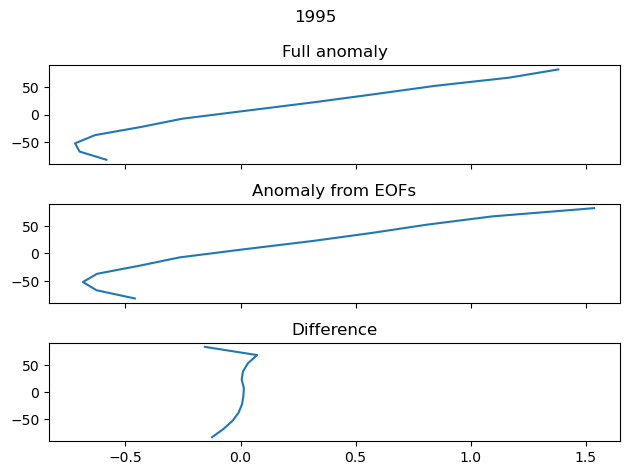

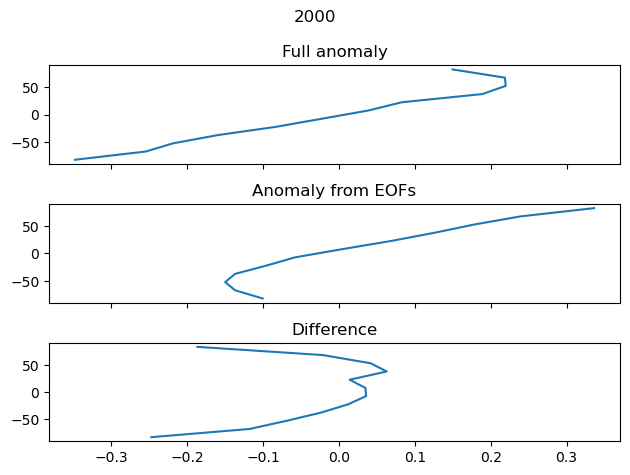

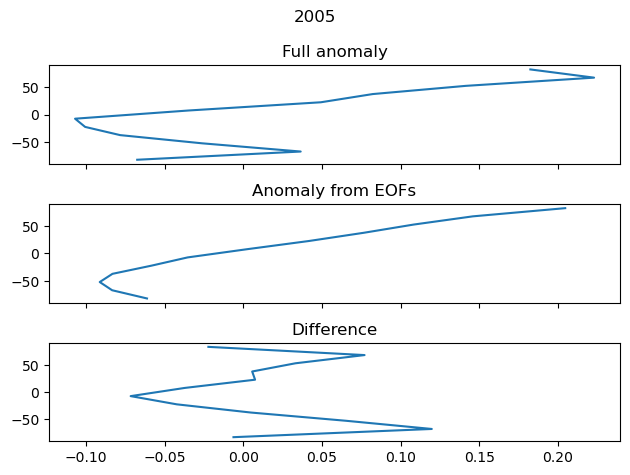

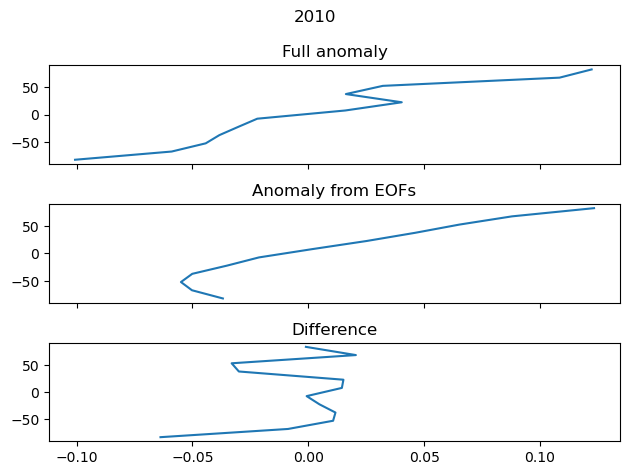

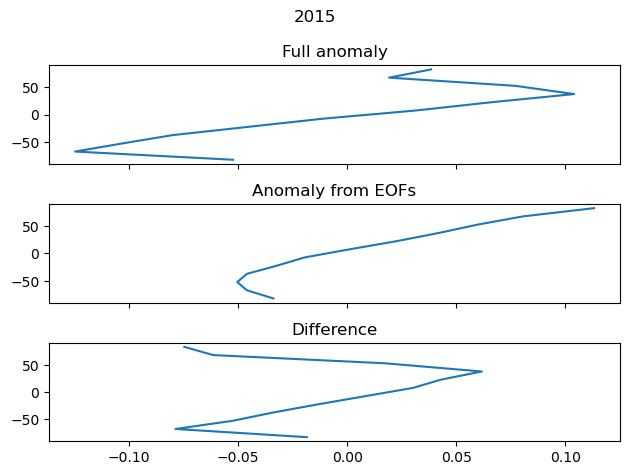

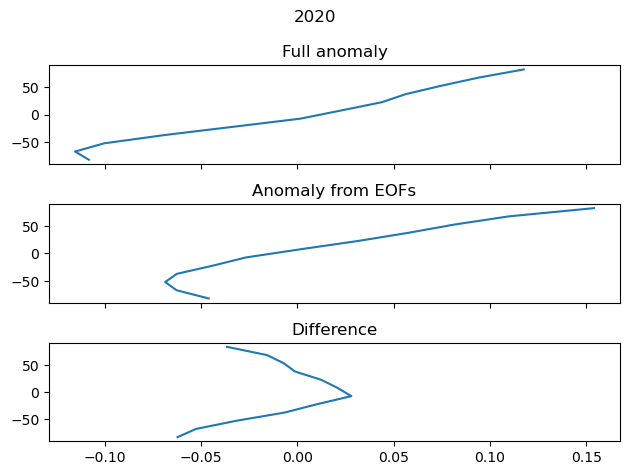

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 16350.18it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 20159.19it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 20115.53it/s]

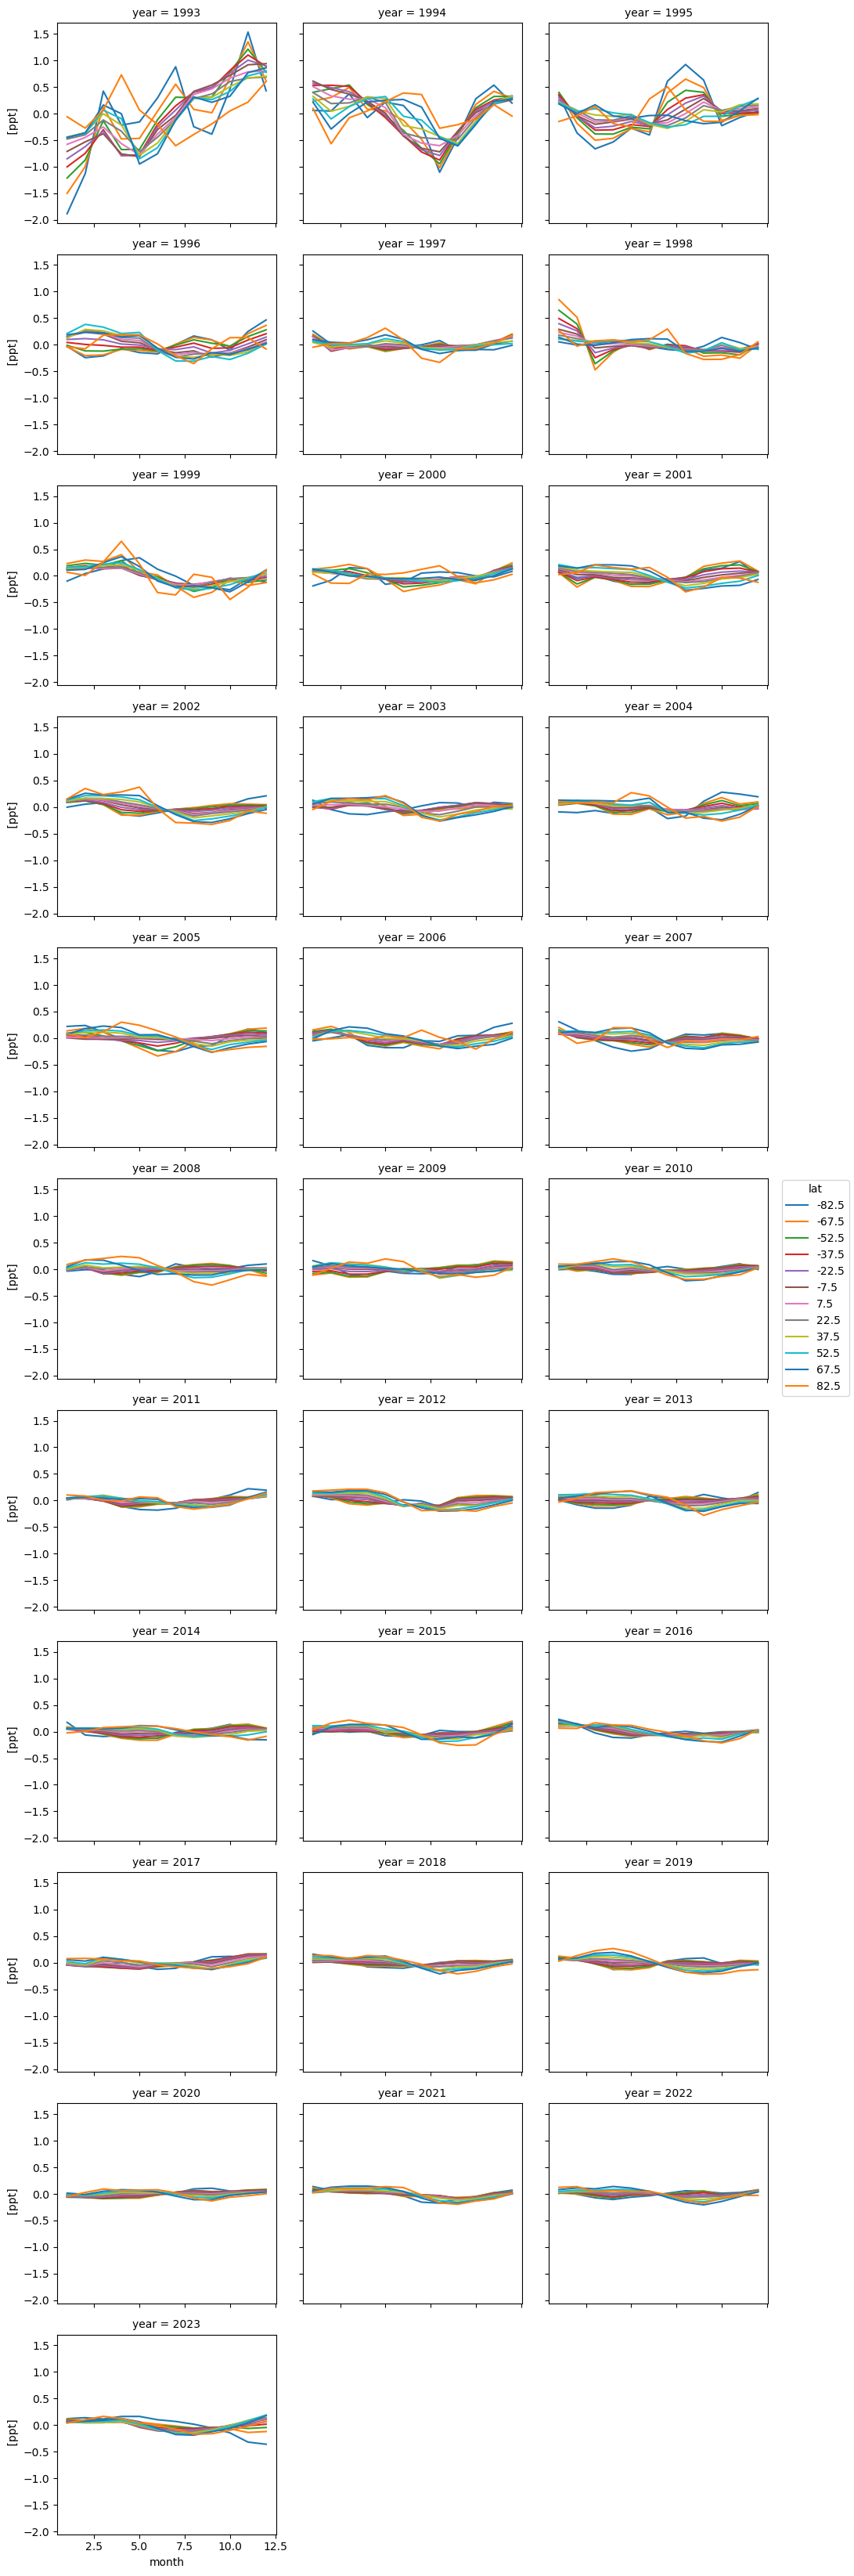

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

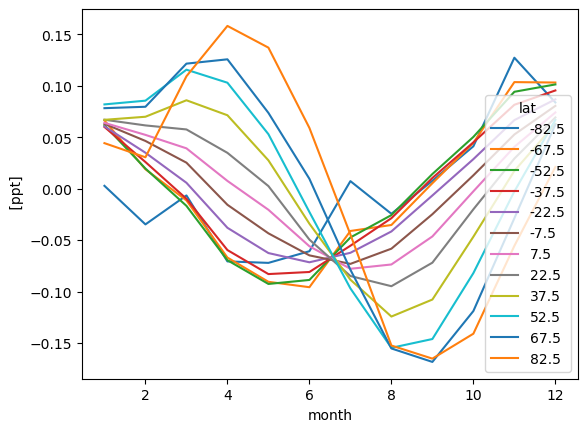

In [22]:
seasonality.plot.line(hue="lat")

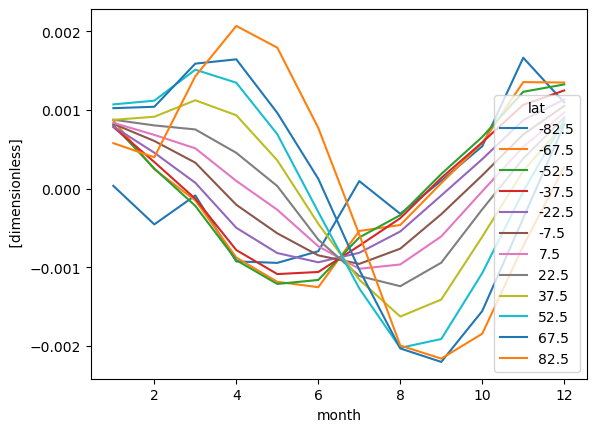

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[82.40353750692468 83.57172788546276 83.81298789384982 83.87375012101684 83.46030946520189 82.98616885757914 82.43297486952252 82.0386716100334 81.50837908365928 80.77554943937429 80.06163477613218 79.28711006119688 78.72783644229035 78.08158592284137 77.28081584246249 76.59208689511247 75.94202397899564 75.28299550097337 74.59673517719294 73.93083729411383 73.25643973901683 72.69177647880524 72.11263927369178 71.48242928061774 70.91318488339182 70.24335931914021 69.55765513516467 68.89834122723754 68.31816085643958 67.75310152969637 67.16913517930486]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.18199277152761673] [0.24784019585397316] [0.2712928553908306] [0.24725244922242925] [0.1732081517124007] [0.10513456823146512] [-0.0072338594128509215] [-0.12422351730821722] [-0.22785836256714267] [-0.3219717114415246] [-0.43381634241216] [-0.6086052036112238]]
Units,ppt
Magnitude,[[-4.813315531600496] [-3.128032057548855] [-2.5244599356646384] [-1.7394435270762652] [-1.3277161385573188] [-0.6958437667970072] [-0.656304245082901] [-0.5523870711835934] [-0.5192037449211997] [-0.6227200931681147] [-0.40674670622211] [-0.40158002180694935] [-0.3362729728382087] [-0.16218128548382185] [-0.18620019729145726] [-0.1235706027149398] [-0.29860305501029644] [-0.20258918481357974] [-0.2127369662001422] [-0.2822067333922683] [-0.3085754578492048] [-0.32163721183474453] [-0.18593876728793685] [-0.268678081519657] [-0.26233371601465333] [-0.15316733909503105] [-0.18298431640389076] [-0.25301375272916077] [-0.08097379490614735] [-0.13042191889703847] [-0.052512007314399194]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[3.538478369714367e-05 -0.00045453478726402533 -8.680911537484656e-05 -0.0009248801173605868 -0.0009437200443099858 -0.0007956530445517608 9.509001190540212e-05 -0.00032000233786778014 9.897065176530111e-05 0.0005381320258286505 0.0016633387404531804 0.0010946812589243725] [0.0008661032484875076 0.00024613952333536277 -0.00014999974711585532 -0.0008761831753380996 -0.0011843355294405534 -0.0012528048871578857 -0.0005383724289110598 -0.000462301359349242 6.859775791490489e-05 0.0005815941577448275 0.0013534082078884547 0.0013481547166407516] [0.00080671618558253 0.0002546936132231077 -0.00021910760497467465 -0.0009095925066765332 -0.0012114446747532525 -0.0011607331051293405 -0.0006208161038523472 -0.0003367365525823209 0.0001854787055170988 0.0006569644568245474 0.0012305220296226981 0.0013240570272528567] [0.0007835131263405115 0.0003379553468040321 -0.00012907295059864986 -0.0007809646248968201 -0.0010859528963742704 -0.0010594834944432803 -0.0007258712634019349 -0.0003759482087371352 0.00013503671954370524 0.0005879467318621025 0.0010654936644461824 0.0012473502085933834] [0.0007910487231159402 0.0004561325581679359 7.415060298540413e-05 -0.0004978650553930003 -0.0008189378777388251 -0.0009363116738991992 -0.0008156923823012147 -0.0005443447237544282 -8.711083410203569e-05 0.0003744911599147658 0.0008704635407859558 0.0011339789872225445] [0.0008234733938505161 0.0006056857064128768 0.00032971753755784924 -0.00020543842460209912 -0.0005683057191466129 -0.0008482765864356754 -0.0009564753084615373 -0.000763283574127046 -0.00032530054965922985 0.00016901874015032184 0.0006878793094357526 0.0010513091624301664] [0.000835825945718693 0.0006828843348669956 0.0005118945932811516 9.790663090333274e-05 -0.0002688747427753745 -0.0007324503123267252 -0.0010188217263866475 -0.0009640155752325101 -0.0006078888375185824 -3.4490647558413904e-05 0.0005302135675086346 0.0009678204792090587] [0.0008753774160961776 0.0008031287097034314 0.0007519646776387342 0.00045454179454791925 3.227648585305113e-05 -0.000648086863836531 -0.001110610527201222 -0.0012400984655190793 -0.000941237796118881 -0.00026300326648642314 0.00038146136998925406 0.0009042902188910126] [0.0008740847261328944 0.0009133581019520053 0.0011227303123253806 0.0009322956648071548 0.0003591750122906098 -0.0004460751844949774 -0.0011574263095081635 -0.0016256908759371864 -0.001409710961764605 -0.0006113077184010718 0.00022566211041373716 0.0008229094001364487] [0.0010702641808365684 0.0011176250660258232 0.001511376746837024 0.0013458264158324209 0.0006918875841102518 -0.00029731282253317177 -0.0012678412986089288 -0.002023322128075518 -0.0019113283665139385 -0.0010736235993904079 -3.583619921968004e-05 0.000872288959144462] [0.0010223421938820821 0.001040189192153673 0.001588145223630926 0.0016430996447571245 0.0009624338993647077 0.00012460958962247766 -0.0010308782674499752 -0.0020310670390490423 -0.0022023579344540734 -0.0015557710625148157 -0.0003763585263753127 0.0008156177546937503] [0.0005778298822407973 0.0003981863075579809 0.0014275909027368777 0.0020674749514501636 0.0017915142709698708 0.0007712634957828214 -0.0005827283580908587 -0.00199403395156261 -0.0021605171056077043 -0.0018438299868009682 -0.0007275795212069984 0.00027483314531779544]]
Units,dimensionless
